### 1. Import the libraries

#### 1.1. Import the needed libraries

In [1]:
from utils.data_loader import DatasetLoader
from utils.data_visualization import DataVisualization
from utils.preprocessing import Preprocessor
from utils.feature_selection import MutualInformation
from utils.models import ensemble_models
from utils.model_evaluator import ModelEvaluator
from utils.tree_shap import SHAPTreeExplainer


import warnings
warnings.filterwarnings('ignore')


#### 1.2. Define the global variables 

In [2]:
binary_target = 'Type' 
multiclass_target = 'Type of attack' 
all_target_columns = [binary_target, multiclass_target]
columns_to_drop = ["Source", "Destination", "Info", "Time"]
categorical_missing_token = None
numeric_imputation_strategy = 'median'
categorical_imputation_strategy = 'most_frequent'
shuffle=True
random_state=80


### 2. Load the dataset

In [3]:
ECU_IoHT_loader = DatasetLoader(dataset_name="ECU_IoHT")

df = ECU_IoHT_loader.load()
df.drop(columns={"No."}, inplace=True)
df = ECU_IoHT_loader.remove_duplicates(df, exclude_column="Time")
df

Duplicated rows: 85393
Dataframe shape: (25814, 8)


,Time,Source,Destination,Protocol,Length,Info,Type,Type of attack
0,0.000000,Alfa_97:cf:63,Broadcast,ARP,42,Who has 192.168.43.1? Tell 192.168.43.186,Attack,ARP Spoofing
1,0.002956,6e:c7:ec:3c:f2:ba,Alfa_97:cf:63,ARP,42,192.168.43.1 is at 6e:c7:ec:3c:f2:ba,Attack,ARP Spoofing
2,0.202713,192.168.43.186,192.168.43.1,DNS,85,Standard query 0x0c44 PTR 1.43.168.192.in-addr...,Normal,No Attack
3,0.431963,192.168.43.1,192.168.43.186,DNS,144,Standard query response 0x0c44 No such name PT...,Normal,No Attack
4,0.433064,192.168.43.186,192.168.43.1,TCP,58,36954 > 1720 [SYN] Seq=0 Win=1024 Len=0 MSS=...,Normal,No Attack
...,...,...,...,...,...,...,...,...
25809,10099.021880,192.168.43.200,52.208.217.22,TCP,395,"[TCP Retransmission] 3850 > 443 [PSH, ACK] S...",Attack,DoS Attack
25810,10099.548430,192.168.43.200,52.208.217.22,TCP,54,3850 > 443 [ACK] Seq=684 Ack=518 Win=4048 Len=0,Normal,No Attack
25811,10099.548490,192.168.43.200,52.208.217.22,TCP,54,[TCP Dup ACK 111171#1] 3850 > 443 [ACK] Seq=...,Normal,No Attack
25812,10099.551450,192.168.43.200,52.208.217.22,TCP,54,"3850 > 443 [RST, ACK] Seq=684 Ack=519 Win=58...",Attack,Nmap Port Scan


### 3. Data Exploration

#### 3.1. Basic Data Analysis

In [4]:
ECU_IoHT_loader.info(df)

,Datatype,Not nulls,Nulls,% Nulls,Unique cnt,Mean,StDev,Min,Q25,Q50,Q75,Max
Time,float64,25814,0,0.0,25812,3882.634508,3818.670287,0.0,252.956799,809.680319,8046.626079,10101.74994
Source,object,25814,0,0.0,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,object,25814,0,0.0,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol,object,25814,0,0.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,int64,25814,0,0.0,794,170.515186,352.922172,42.0,54.000000,58.000000,66.000000,1474.00000
Info,object,25814,0,0.0,24010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,object,25814,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of attack,object,25814,0,0.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
attack_ranges = (
    df.groupby("Type of attack")["Time"]
      .agg(["min", "max", "count"])
      .sort_values("min")
)

attack_ranges

,min,max,count
Type of attack,,,
ARP Spoofing,0.000000,7929.945144,264
No Attack,0.202713,10101.749940,18366
Nmap Port Scan,0.438592,10099.551450,6658
Smurf Attack,256.976351,9977.841364,32
DoS Attack,257.102639,10099.021880,494


#### 3.2. Target Features

In [6]:
viz = DataVisualization(
    df,
    label_columns=all_target_columns
)


##### 3.2.1. Binary class

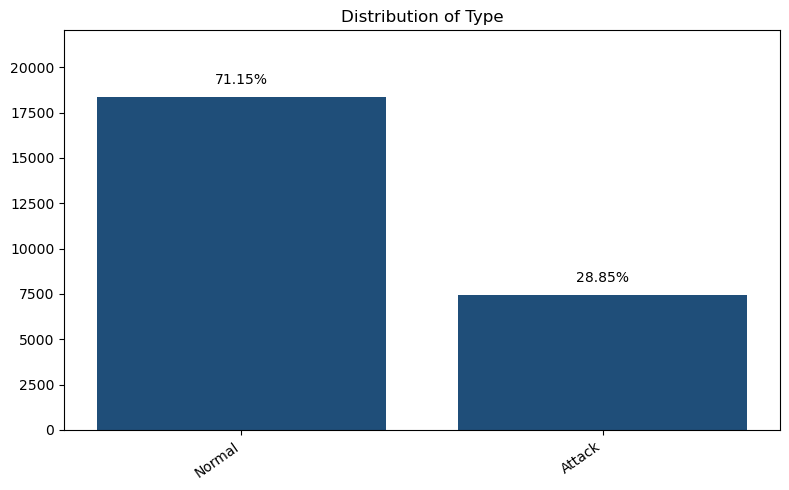

In [7]:
viz.target_distribution(
    label_column=binary_target
)


##### 3.2.2. Multiclass

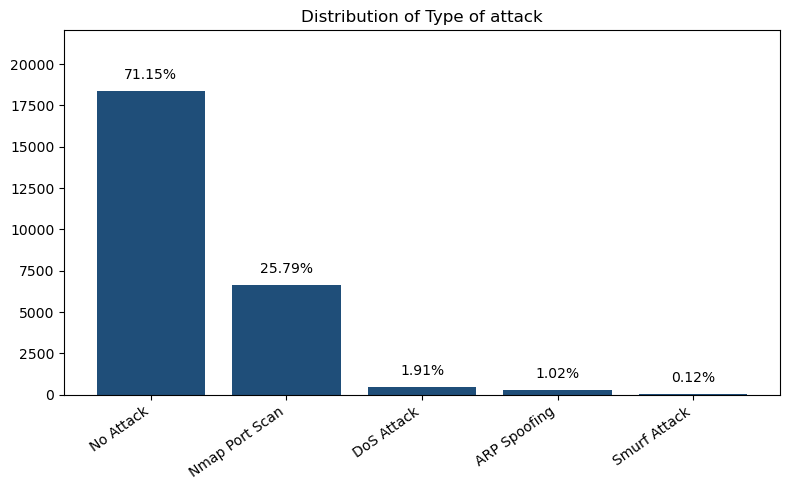

In [8]:
viz.target_distribution(label_column=multiclass_target)


#### 3.3. Numerical Data

Histogram

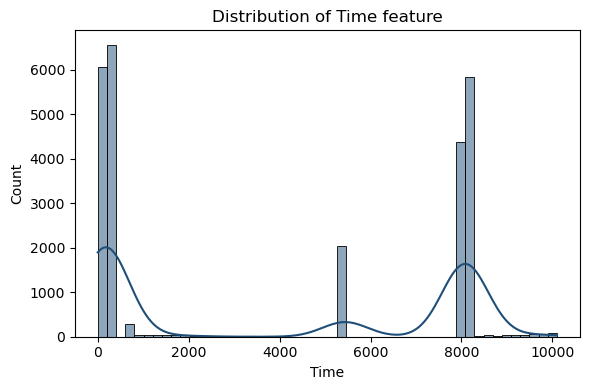

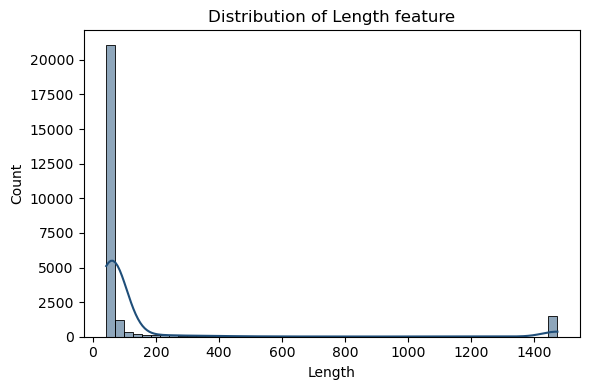

In [9]:
viz.numeric_distribution()


Boxplot

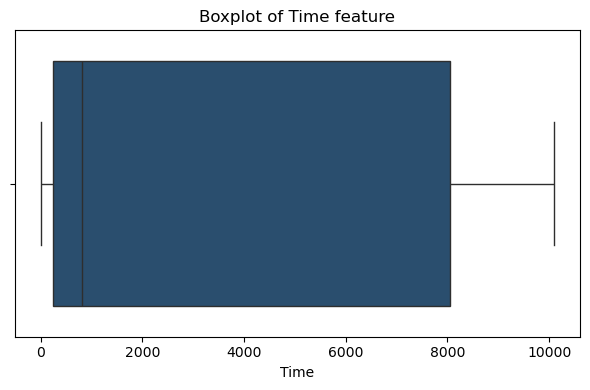

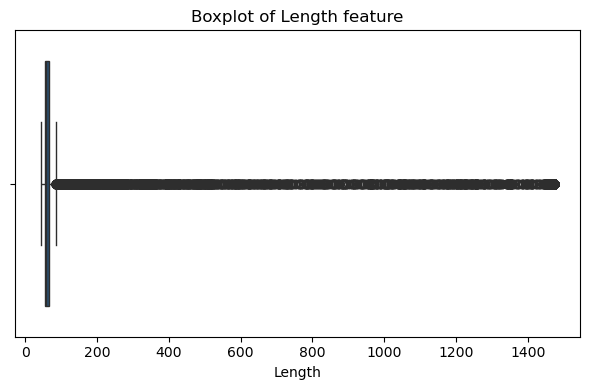

In [10]:
viz.boxplot()

#### 3.4. Categorical Data

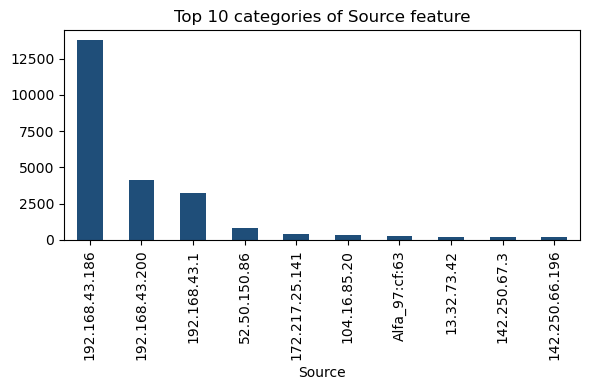

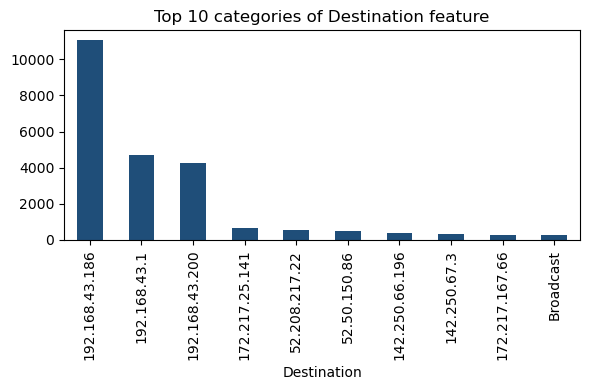

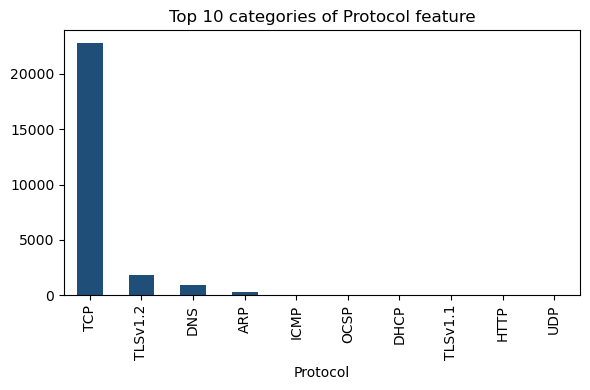

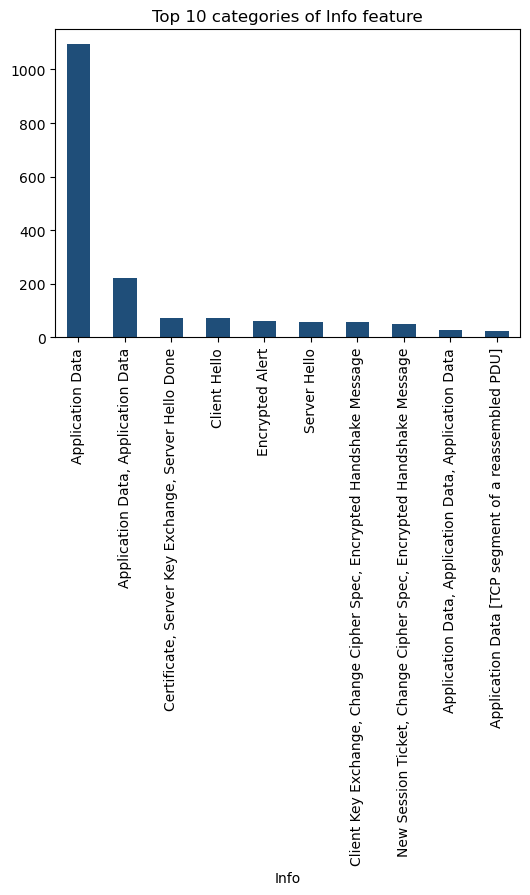

In [11]:
viz.categorical_distribution()

### 4. Preprocessing

#### 4.1. Binary class

In [12]:
preprocessor_BC = Preprocessor(
    target_column=binary_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_BC = preprocessor_BC.prepare_features(df)

X_BC = df_BC.drop(columns=[binary_target]).reset_index(drop=True)
y_BC = df_BC[binary_target].reset_index(drop=True)


['Type of attack'] target column eliminated
['Source', 'Destination', 'Info', 'Time'] columns eliminated


#### 4.2. Multiclass

In [13]:
preprocessor_MC = Preprocessor(
    target_column=multiclass_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_MC = preprocessor_MC.prepare_features(df)

X_MC = df_MC.drop(columns=[multiclass_target]).reset_index(drop=True)
y_MC = df_MC[multiclass_target].reset_index(drop=True)


['Type'] target column eliminated
['Source', 'Destination', 'Info', 'Time'] columns eliminated


### 5. Feature Selection

#### 5.1. Binary class

In [14]:
mi_BC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


#### 5.2. Multiclass

In [15]:
mi_MC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


### 6. Train the models

#### 6.1. Binary class

In [16]:
# Models with default parameters
models_BC = ensemble_models(task_type="binary", random_state=random_state)
models_BC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

{'Attack': 0, 'Normal': 1}
X_train shape: (12907, 2)
y_train shape: (12907,)
X_test shape: (12907, 2)
y_test shape: (12907,)
1 numeric features: ['Length']
1 categorical features: ['Protocol']
Total features after preprocessing: 11
Mutual Information selected 1 features: ['Length']

Running model: RandomForest


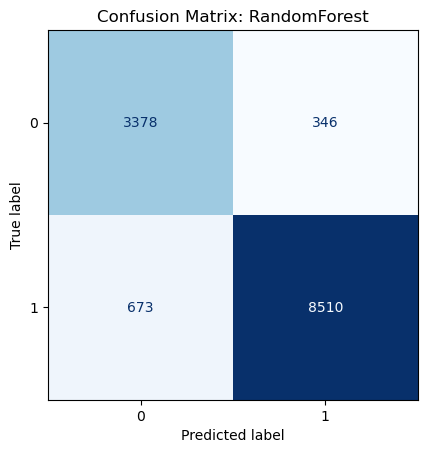


Running model: ExtraTrees


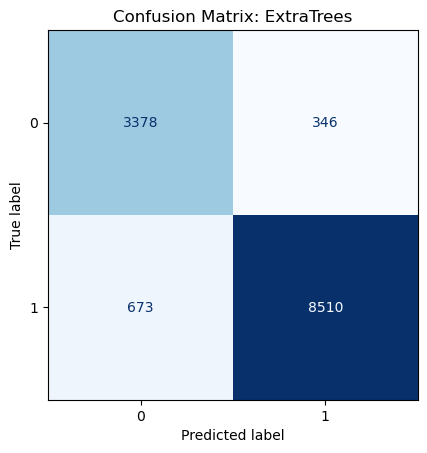


Running model: LightGBM


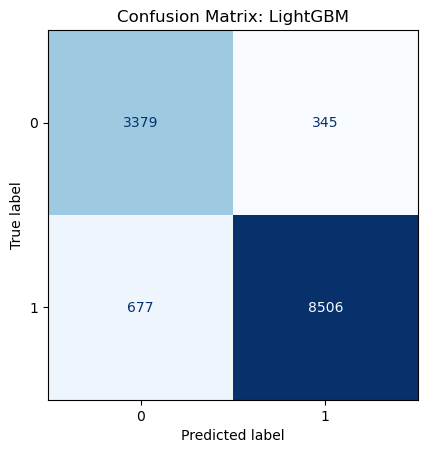


Running model: XGBoost


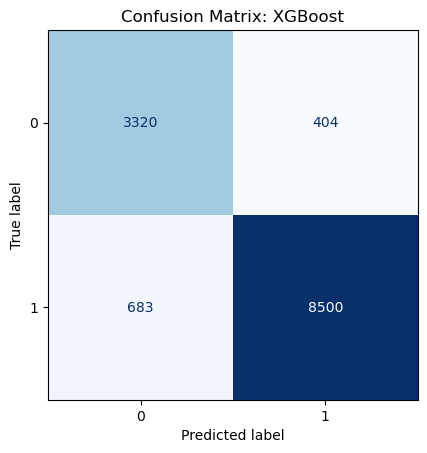

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,training_time_s,inference_time_per_sample_ms
0,RandomForest,0.926706,0.921051,0.963534,0.960930,0.932266,0.926712,0.947642,0.943511,0.279064,0.002649
1,ExtraTrees,0.926706,0.921051,0.963743,0.960930,0.932048,0.926712,0.947631,0.943511,0.220553,0.003307
2,LightGBM,0.925389,0.920818,0.963151,0.961021,0.930742,0.926277,0.946669,0.943329,1.786189,0.000685
3,XGBoost,0.921283,0.915782,0.957330,0.954627,0.930850,0.925623,0.943905,0.939902,0.150524,0.000243


In [17]:
runner_BC = ModelEvaluator(
    test_size=0.5,
    random_state=random_state,
    task_type="binary",
    split_strategy="stratified"
)

results_BC = runner_BC.run(
    models=models_BC,
    preprocessor=preprocessor_BC,
    X=X_BC,
    y=y_BC,
    feature_selector=mi_BC
)

results_BC


#### 6.2. Multiclass

In [18]:
models_MC = ensemble_models(task_type="multiclass", random_state=random_state)
models_MC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

{'ARP Spoofing': 0, 'DoS Attack': 1, 'Nmap Port Scan': 2, 'No Attack': 3, 'Smurf Attack': 4}
X_train shape: (12907, 2)
y_train shape: (12907,)
X_test shape: (12907, 2)
y_test shape: (12907,)
1 numeric features: ['Length']
1 categorical features: ['Protocol']
Total features after preprocessing: 11
Mutual Information selected 3 features: ['Length', 'Protocol_TCP', 'Protocol_ARP']

Running model: RandomForest


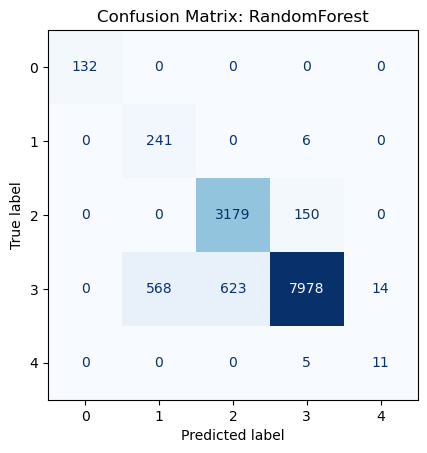


Running model: ExtraTrees


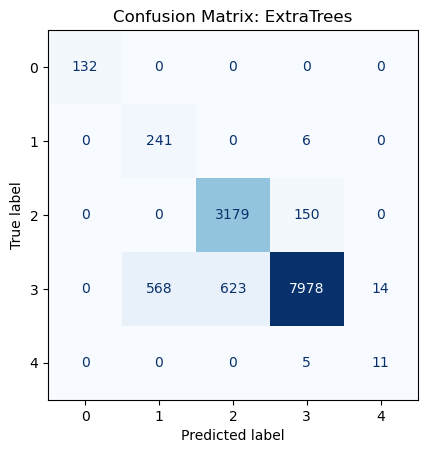


Running model: LightGBM


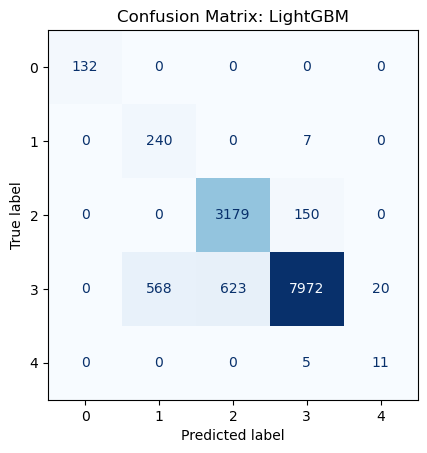


Running model: XGBoost


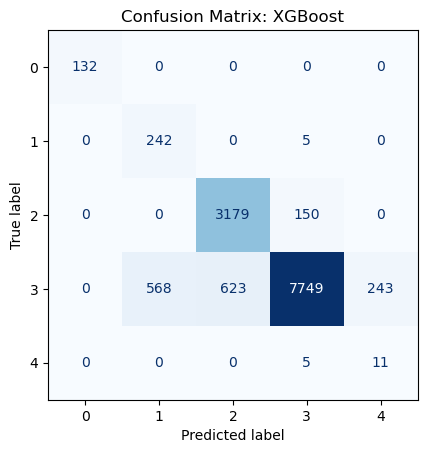

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,training_time_s,inference_time_per_sample_ms
0,RandomForest,0.893004,0.894166,0.712208,0.710851,0.961913,0.897386,0.777660,0.761153,0.240291,0.002784
1,ExtraTrees,0.893004,0.894166,0.712208,0.710851,0.961913,0.897386,0.777660,0.761153,0.213607,0.003398
2,LightGBM,0.892229,0.893624,0.697508,0.693618,0.961695,0.896445,0.762669,0.747075,0.176784,0.002410
3,XGBoost,0.875804,0.876501,0.635578,0.631596,0.957078,0.893208,0.675135,0.667544,0.165235,0.000561


In [19]:
runner_MC = ModelEvaluator(
    test_size=0.5,
    random_state=random_state,
    task_type="multiclass",
    split_strategy="stratified"
)

results_MC = runner_MC.run(
    models=models_MC,
    preprocessor=preprocessor_MC,
    X=X_MC,
    y=y_MC,
    feature_selector=mi_MC
)

results_MC



### 7. TreeSHAP

#### 7.1. Multiclass

In [20]:
explainer_MC = SHAPTreeExplainer(task_type="multiclass", n_samples=3000, random_state=random_state) 

RandomForest

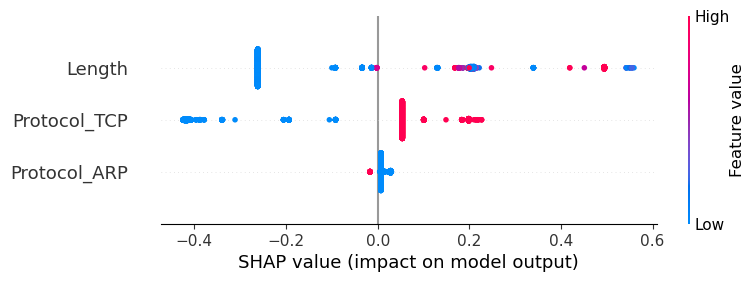

In [21]:
model_MC_rf, X_train_MC_rf, y_train_MC_rf, X_test_MC_rf, y_test_MC_rf = (
    runner_MC.get_model_data("RandomForest")
)

explainer_MC.plot_beeswarm(model_MC_rf, X_test_MC_rf, class_index=1)

ExtraTrees

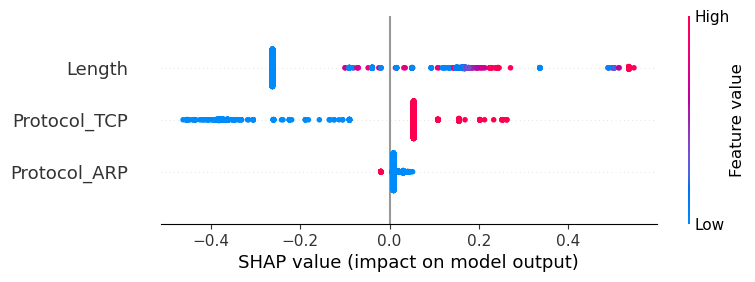

In [22]:
model_MC_et, X_train_MC_et, y_train_MC_et, X_test_MC_et, y_test_MC_et = (
    runner_MC.get_model_data("ExtraTrees")
)

explainer_MC.plot_beeswarm(model_MC_et, X_test_MC_et, class_index=1)

XGBoost

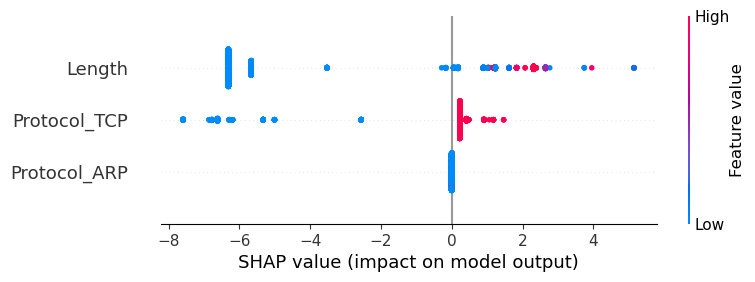

In [23]:
model_MC_xg, X_train_MC_xg, y_train_MC_xg, X_test_MC_xg, y_test_MC_xg = (
    runner_MC.get_model_data("XGBoost")
)

explainer_MC.plot_beeswarm(model_MC_xg, X_test_MC_xg, class_index=1)

LightGBM

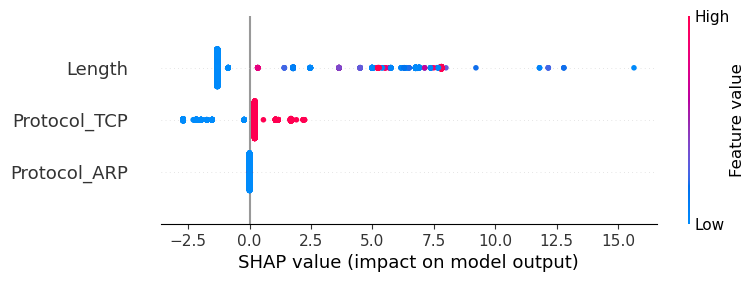

In [24]:
model_MC_lb, X_train_MC_lb, y_train_MC_lb, X_test_MC_lb, y_test_MC_lb = (
    runner_MC.get_model_data("LightGBM")
)

explainer_MC.plot_beeswarm(model_MC_lb, X_test_MC_lb, class_index=1)